In [4]:
# ==========================================================
# 1. SETUP & SENSITIVITY ENGINE (FIXED)
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

print("--- Setup Complete ---")

def get_imputation_accuracy(name, df):

    # 1. Drop columns that are totally empty
    df = df.dropna(axis=1, how='all')

    # 2. CAPTURE SAMPLE SIZE (This was missing in your paste)
    n_samples = len(df)

    # 3. Scale (KNN requires scaled data)
    scaler = StandardScaler()
    try:
        df_scaled_array = scaler.fit_transform(df)
        df_scaled = pd.DataFrame(df_scaled_array, columns=df.columns)
    except:
        return []

    imputer = KNNImputer(n_neighbors=5)

    results = []

    # 4. Loop through every column
    for col in df.columns:
        valid_indices = df_scaled[df_scaled[col].notna()].index
        if len(valid_indices) < 50:
            continue

        # A. Hide Data
        data_test = df_scaled.copy()
        np.random.seed(42)
        mask_indices = np.random.choice(valid_indices, size=int(len(valid_indices)*0.2), replace=False)

        true_values = df_scaled.loc[mask_indices, col]
        data_test.loc[mask_indices, col] = np.nan

        # B. Recovery
        data_imputed = imputer.fit_transform(data_test)
        data_imputed_df = pd.DataFrame(data_imputed, columns=df.columns)

        # C. Compare
        guessed_values = data_imputed_df.loc[mask_indices, col]

        mae = mean_absolute_error(true_values, guessed_values)
        r2 = r2_score(true_values, guessed_values)

        results.append({
            "Combination": name,
            "Sample Size": n_samples,
            "Feature": col,
            "MAE (Error)": mae,
            "R2 (Accuracy)": r2
        })

    return results

--- Setup Complete ---


In [5]:
# ==========================================================
# 2. EXECUTE ON 15 COMBINATIONS
# ==========================================================
print("--- Loading Raw Data ---")
cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
        'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

def load_clean(url):
    # Read and force numeric, drop target for this test (we only validate features)
    df = pd.read_csv(url, names=cols, na_values='?')
    return df.drop('target', axis=1)

# Load
datasets = {
    "A": load_clean("https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"),
    "B": load_clean("https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.hungarian.data"),
    "C": load_clean("https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.switzerland.data"),
    "D": load_clean("https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.va.data")
}

# Generate 15 Combinations
combos = []
for r in range(1, 5):
    combos.extend(itertools.combinations(datasets.keys(), r))

print(f" Testing Imputation Accuracy on {len(combos)} Dataset Combinations...\n")

global_imputation_stats = []

for combo in combos:
    combo_name = "+".join(combo)

    # Merge
    dfs_list = [datasets[k] for k in combo]
    df_combined = pd.concat(dfs_list, axis=0, ignore_index=True)

    # Run Test
    print(f"   > Analyzing: {combo_name}...")
    stats = get_imputation_accuracy(combo_name, df_combined)
    global_imputation_stats.extend(stats)

print("\n Validation Complete.")

--- Loading Raw Data ---
 Testing Imputation Accuracy on 15 Dataset Combinations...

   > Analyzing: A...
   > Analyzing: B...
   > Analyzing: C...
   > Analyzing: D...
   > Analyzing: A+B...
   > Analyzing: A+C...
   > Analyzing: A+D...
   > Analyzing: B+C...
   > Analyzing: B+D...
   > Analyzing: C+D...
   > Analyzing: A+B+C...
   > Analyzing: A+B+D...
   > Analyzing: A+C+D...
   > Analyzing: B+C+D...
   > Analyzing: A+B+C+D...

 Validation Complete.



 IMPUTATION ACCURACY MATRIX (R2 Score)
   (1.0 = Perfect Guess | 0.0 = Random Guess)


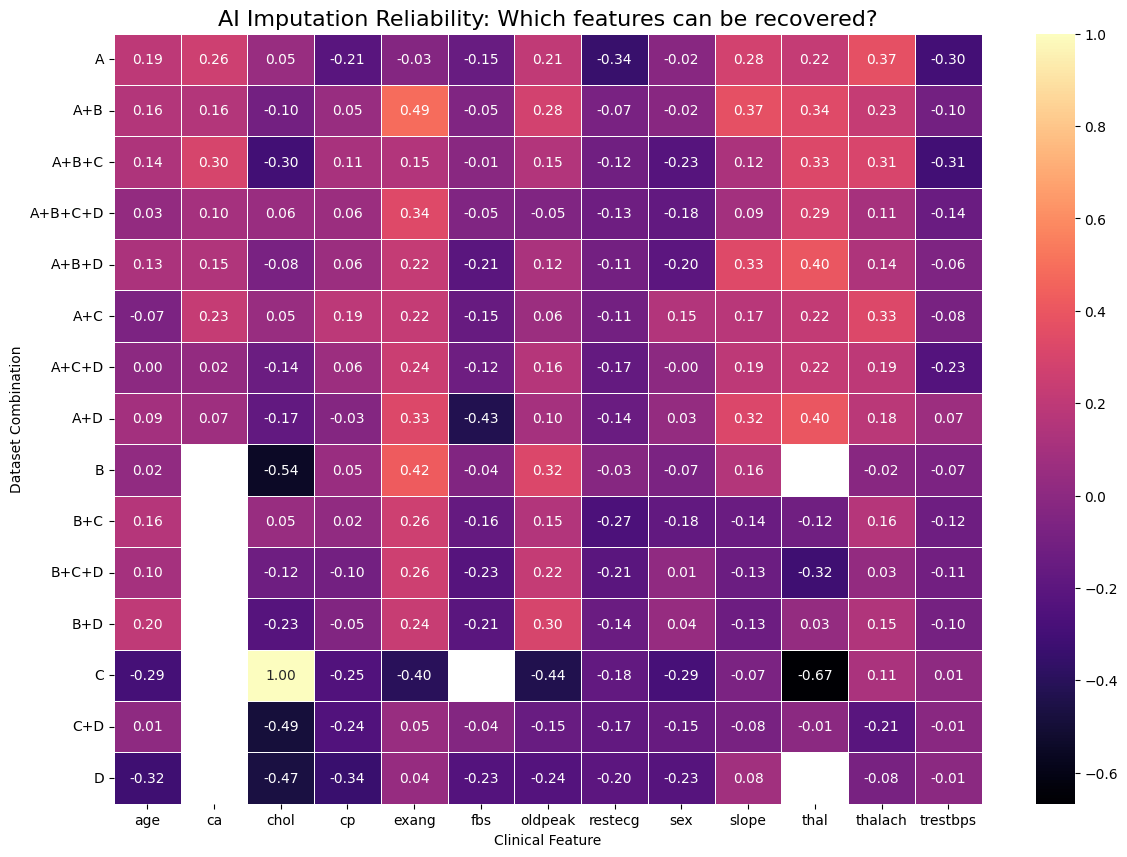


 FULL RELIABILITY REPORT [Image of data cleaning filter process]


,Combination,Sample Size,Feature,R2 (Accuracy),MAE (Error)
28,C,123,chol,1.000000,0.000000
54,A+B,597,exang,0.487980,0.484647
21,B,294,exang,0.420746,0.554870
146,A+B+D,797,thal,0.400173,0.583414
84,A+D,503,thal,0.399947,0.554520
7,A,303,thalach,0.373693,0.672148
56,A+B,597,slope,0.368983,0.548165
58,A+B,597,thal,0.340457,0.645446
180,A+B+C+D,920,exang,0.335477,0.592663
144,A+B+D,797,slope,0.334329,0.669528


In [6]:
# ==========================================================
# 3. VISUALIZE AI GUESSING ACCURACY (R2 SCORE)
# ==========================================================
print("\n" + "="*60)
print(" IMPUTATION ACCURACY MATRIX (R2 Score)")
print("   (1.0 = Perfect Guess | 0.0 = Random Guess)")
print("="*60)

# 1. Process Data
df_res = pd.DataFrame(global_imputation_stats)

# 2. Pivot Table
pivot_r2 = df_res.pivot(index="Combination", columns="Feature", values="R2 (Accuracy)")

# 3. Plot Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(pivot_r2, annot=True, fmt=".2f", cmap="magma", linewidths=0.5)
plt.title("AI Imputation Reliability: Which features can be recovered?", fontsize=16)
plt.ylabel("Dataset Combination")
plt.xlabel("Clinical Feature")
plt.show()

# 4. THE FULL LIST (With Sample Size)
print("\n FULL RELIABILITY REPORT [Image of data cleaning filter process]")
print("="*60)

# Configure Pandas to show ALL rows
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)

# Select columns
cols_to_show = ['Combination', 'Sample Size', 'Feature', 'R2 (Accuracy)', 'MAE (Error)']

# Display
display(df_res.sort_values(by="R2 (Accuracy)", ascending=False)[cols_to_show])

# Reset
pd.reset_option('display.max_rows')


 RUNNING ROBUST STRESS TEST (Adaptive Pruning)
Testing 15 Combinations...

    A: Error 0.7795 (Tested on 297 valid rows)
    B: Error 0.7769 (Tested on 95 valid rows)
    C: Error 0.7246 (Tested on 43 valid rows)
    D: Error 0.7865 (Tested on 17 valid rows)
    A + B: Error 0.7780 (Tested on 298 valid rows)
    A + C: Error 0.7795 (Tested on 297 valid rows)
    A + D: Error 0.7804 (Tested on 298 valid rows)
    B + C: Error 0.7532 (Tested on 53 valid rows)
    B + D: Error 0.8236 (Tested on 27 valid rows)
    C + D: Error 0.8140 (Tested on 60 valid rows)
    A + B + C: Error 0.7780 (Tested on 298 valid rows)
    A + B + D: Error 0.7768 (Tested on 299 valid rows)
    A + C + D: Error 0.7804 (Tested on 298 valid rows)
    B + C + D: Error 0.7234 (Tested on 70 valid rows)
    A + B + C + D: Error 0.7768 (Tested on 299 valid rows)

 FINAL STABILITY REPORT (All 15 Combinations)


/tmp/ipykernel_10327/2823761142.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Dataset Combo", y="Stability Error", data=df_stress, palette=pal)


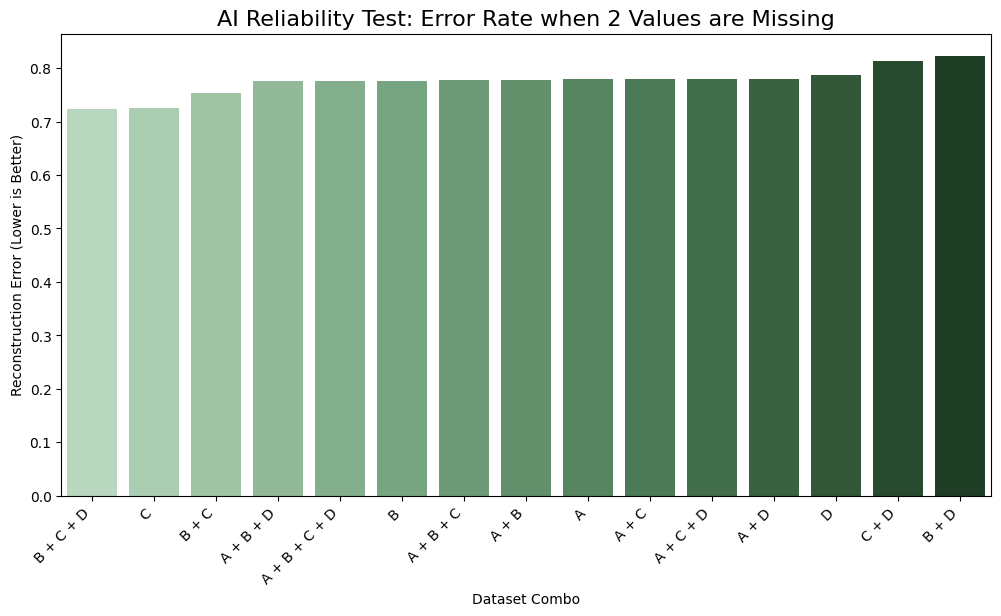

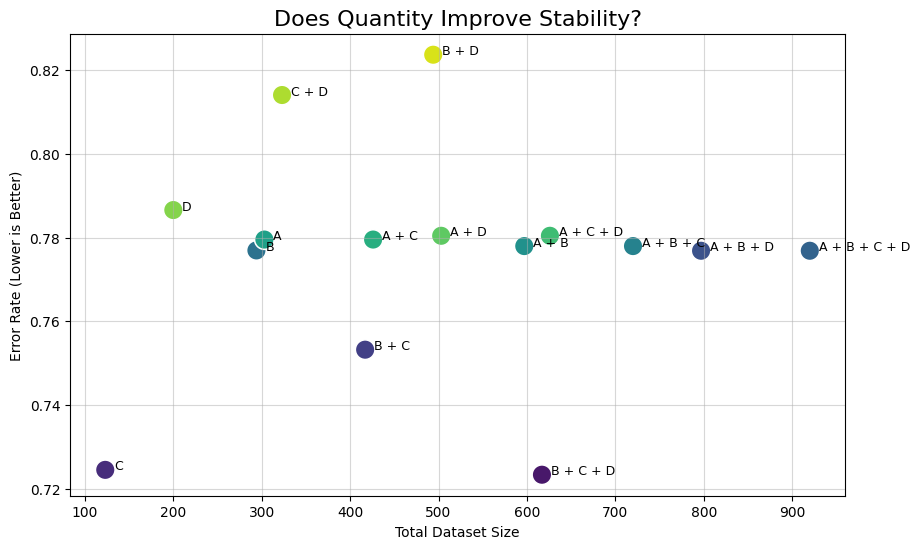


 MOST STABLE DATASET: **B + C + D**
   When 2 values are missing, the AI can reconstruct them with only **0.7234** error.


In [7]:
# ==========================================================
# 4. STABILITY STRESS TEST: 2 MISSING VALUES (ALL 15 COMBOS)
# ==========================================================
import itertools
from sklearn.metrics import mean_absolute_error # Ensure metric is imported

print("\n" + "="*60)
print(" RUNNING ROBUST STRESS TEST (Adaptive Pruning)")
print("="*60)

def run_2_missing_stress_test_robust(name, df):
    # --- 1. ADAPTIVE CLEANING ---
    # Goal: Find a subset of data that is "Complete" to serve as Ground Truth

    # First, try standard drop
    df_clean = df.dropna()

    # If that leaves us with no data (e.g., Switzerland), be smarter:
    if len(df_clean) < 10:
        # Strategy: Drop the worst columns until we get rows back
        # Calculate missingness per column
        missing_pct = df.isnull().mean()
        # Drop columns with ANY missing data, starting from worst
        cols_sorted = missing_pct.sort_values(ascending=False).index

        temp_df = df.copy()
        for col in cols_sorted:
            if temp_df.isnull().sum().sum() == 0: break # Stop if clean
            if len(temp_df.dropna()) > 10: break # Stop if we have enough rows
            temp_df = temp_df.drop(col, axis=1)

        df_clean = temp_df.dropna()

    # If STILL no data (very rare), return fail
    if len(df_clean) < 10:
        return None

    # --- 2. PREPARE GROUND TRUTH ---
    # We strictly use the clean rows as the "Answer Key"
    scaler = StandardScaler()
    try:
        data_clean = scaler.fit_transform(df_clean)
    except:
        return None

    # --- 3. SIMULATION: HIDE EXACTLY 2 VALUES PER ROW ---
    n_rows, n_cols = data_clean.shape
    if n_cols < 3: return None # Need at least 3 cols to hide 2 and guess

    data_broken = data_clean.copy()
    np.random.seed(42)

    mask = np.zeros_like(data_broken, dtype=bool)

    for i in range(n_rows):
        # Randomly pick 2 distinct column indices to hide
        missing_indices = np.random.choice(n_cols, size=2, replace=False)
        mask[i, missing_indices] = True
        data_broken[i, missing_indices] = np.nan

    # --- 4. RECOVERY (KNN Imputation) ---
    # This is the AI trying to fix the holes we just made
    imputer = KNNImputer(n_neighbors=5)
    data_healed = imputer.fit_transform(data_broken)

    # --- 5. MEASURE ERROR ---
    true_missing = data_clean[mask]
    guessed_missing = data_healed[mask]

    stability_error = mean_absolute_error(true_missing, guessed_missing)

    return {
        "Dataset Combo": name,
        "Sample Size": len(df),
        "Valid Rows Used": n_rows,
        "Features Tested": n_cols,
        "Stability Error": stability_error
    }

# --- EXECUTE LOOP (Ensuring all 15) ---
combos = []
for r in range(1, 5):
    combos.extend(itertools.combinations(datasets.keys(), r))

stress_results = []

print(f"Testing {len(combos)} Combinations...\n")

for combo in combos:
    combo_name = " + ".join([k[0] for k in combo])

    # Merge Data
    dfs_list = [datasets[k] for k in combo]
    df_combined = pd.concat(dfs_list, axis=0, ignore_index=True)

    # FIX: Use errors='ignore' to prevent crashing if 'target' is already gone
    df_combined = df_combined.drop('target', axis=1, errors='ignore')

    # Run Robust Test
    res = run_2_missing_stress_test_robust(combo_name, df_combined)

    if res:
        stress_results.append(res)
        print(f"    {combo_name}: Error {res['Stability Error']:.4f} (Tested on {res['Valid Rows Used']} valid rows)")
    else:
        print(f"    {combo_name}: Insufficient Data even after pruning.")

# --- VISUALIZE ---
df_stress = pd.DataFrame(stress_results).sort_values(by="Stability Error", ascending=True)

print("\n" + "="*60)
print(" FINAL STABILITY REPORT (All 15 Combinations)")
print("="*60)

# Plot 1: Stability Ranking
plt.figure(figsize=(12, 6))
# Green = Stable, Red = Unstable
pal = sns.cubehelix_palette(len(df_stress), start=2, rot=0, dark=0.2, light=.8)
sns.barplot(x="Dataset Combo", y="Stability Error", data=df_stress, palette=pal)

plt.title("AI Reliability Test: Error Rate when 2 Values are Missing", fontsize=16)
plt.ylabel("Reconstruction Error (Lower is Better)")
plt.xticks(rotation=45, ha='right')
plt.show()

# Plot 2: Dataset Size vs Stability
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_stress,
    x="Sample Size",
    y="Stability Error",
    hue="Dataset Combo",
    s=200,
    palette="viridis",
    legend=False
)

for i in range(len(df_stress)):
    row = df_stress.iloc[i]
    plt.text(row['Sample Size']+10, row['Stability Error'], row['Dataset Combo'], fontsize=9)

plt.title("Does Quantity Improve Stability?", fontsize=16)
plt.xlabel("Total Dataset Size")
plt.ylabel("Error Rate (Lower is Better)")
plt.grid(True, alpha=0.5)
plt.show()

# Final Verdict
winner = df_stress.iloc[0]
print(f"\n MOST STABLE DATASET: **{winner['Dataset Combo']}**")
print(f"   When 2 values are missing, the AI can reconstruct them with only **{winner['Stability Error']:.4f}** error.")

--- Reloading Data to ensure variables exist ---

 RUNNING STRESS TEST: 1 MISSING VALUE PER PATIENT
Testing 15 Combinations...

   A: Error 0.7576 (Used 297 rows)
   B: Error 0.7214 (Used 95 rows)
   C: Error 0.7059 (Used 43 rows)
   D: Error 0.7286 (Used 17 rows)
   A + B: Error 0.7578 (Used 298 rows)
   A + C: Error 0.7576 (Used 297 rows)
   A + D: Error 0.7569 (Used 298 rows)
   B + C: Error 0.6230 (Used 53 rows)
   B + D: Error 0.8221 (Used 27 rows)
   C + D: Error 0.7333 (Used 60 rows)
   A + B + C: Error 0.7578 (Used 298 rows)
   A + B + D: Error 0.7548 (Used 299 rows)
   A + C + D: Error 0.7569 (Used 298 rows)
   B + C + D: Error 0.6088 (Used 70 rows)
   A + B + C + D: Error 0.7548 (Used 299 rows)

 FINAL STABILITY REPORT (1 Missing Value)


/tmp/ipykernel_10327/127446705.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Dataset Combo", y="Stability Error", data=df_stress, palette=pal)


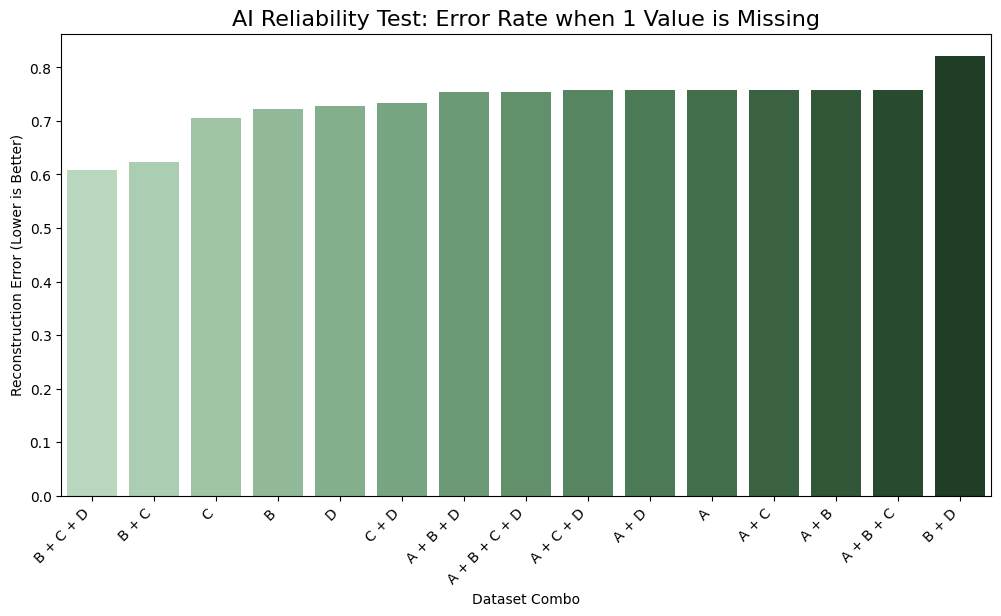

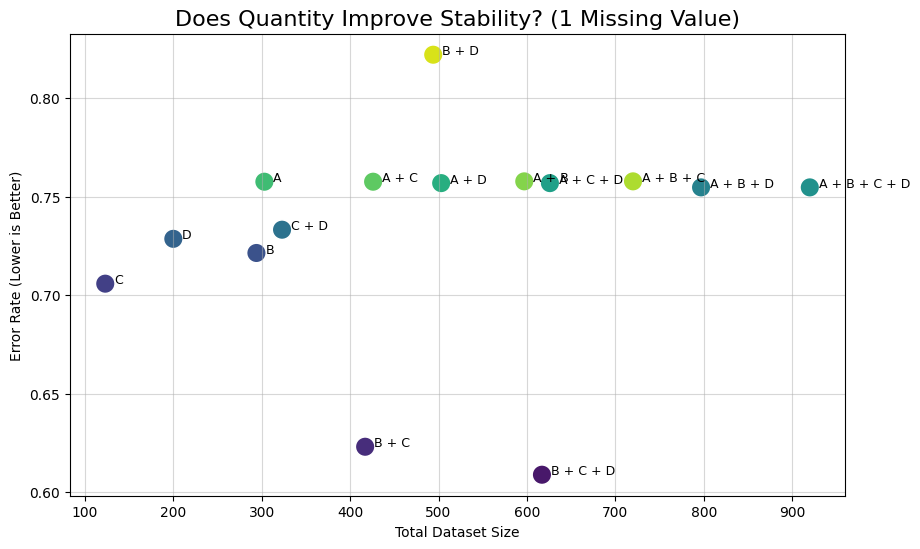


🏆 MOST STABLE DATASET: **B + C + D**
   Error Rate: **0.6088**
   (This dataset is the best at fixing single clerical errors).


In [8]:
# ==========================================================
# 4. STABILITY STRESS TEST: 1 MISSING VALUE (STANDALONE)
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

print("--- Reloading Data to ensure variables exist ---")
cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
        'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

def load_clean(url):
    # Read and force numeric, drop target for this test
    df = pd.read_csv(url, names=cols, na_values='?')
    return df.drop('target', axis=1)

# Load datasets again to fix NameError
datasets = {
    "A": load_clean("https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"),
    "B": load_clean("https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.hungarian.data"),
    "C": load_clean("https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.switzerland.data"),
    "D": load_clean("https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.va.data")
}

print("\n" + "="*60)
print(" RUNNING STRESS TEST: 1 MISSING VALUE PER PATIENT")
print("="*60)

def run_1_missing_stress_test_robust(name, df):
    # --- 1. ADAPTIVE CLEANING ---
    df_clean = df.dropna()

    # If data is too sparse (Swiss/VA), prune bad columns
    if len(df_clean) < 10:
        missing_pct = df.isnull().mean()
        cols_sorted = missing_pct.sort_values(ascending=False).index
        temp_df = df.copy()
        for col in cols_sorted:
            if temp_df.isnull().sum().sum() == 0: break
            if len(temp_df.dropna()) > 10: break
            temp_df = temp_df.drop(col, axis=1)
        df_clean = temp_df.dropna()

    if len(df_clean) < 10: return None

    # --- 2. PREPARE GROUND TRUTH ---
    scaler = StandardScaler()
    try:
        data_clean = scaler.fit_transform(df_clean)
    except:
        return None

    # --- 3. SIMULATION: HIDE EXACTLY 1 VALUE PER ROW ---
    n_rows, n_cols = data_clean.shape
    if n_cols < 2: return None

    data_broken = data_clean.copy()
    np.random.seed(42)

    mask = np.zeros_like(data_broken, dtype=bool)

    for i in range(n_rows):
        # Hide exactly 1 value
        missing_indices = np.random.choice(n_cols, size=1, replace=False)
        mask[i, missing_indices] = True
        data_broken[i, missing_indices] = np.nan

    # --- 4. RECOVERY ---
    imputer = KNNImputer(n_neighbors=5)
    data_healed = imputer.fit_transform(data_broken)

    # --- 5. MEASURE ERROR ---
    true_missing = data_clean[mask]
    guessed_missing = data_healed[mask]

    stability_error = mean_absolute_error(true_missing, guessed_missing)

    return {
        "Dataset Combo": name,
        "Sample Size": len(df),
        "Valid Rows Used": n_rows,
        "Features Tested": n_cols,
        "Stability Error": stability_error
    }

# --- EXECUTE LOOP ---
combos = []
for r in range(1, 5):
    combos.extend(itertools.combinations(datasets.keys(), r))

stress_results = []
print(f"Testing {len(combos)} Combinations...\n")

for combo in combos:
    combo_name = " + ".join([k[0] for k in combo])

    # Merge Data
    dfs_list = [datasets[k] for k in combo]
    df_combined = pd.concat(dfs_list, axis=0, ignore_index=True)

    # FIX: Drop target safely
    df_combined = df_combined.drop('target', axis=1, errors='ignore')

    # Run Test
    res = run_1_missing_stress_test_robust(combo_name, df_combined)

    if res:
        stress_results.append(res)
        print(f"   {combo_name}: Error {res['Stability Error']:.4f} (Used {res['Valid Rows Used']} rows)")
    else:
        print(f"   {combo_name}: Insufficient Data.")

# --- VISUALIZE ---
df_stress = pd.DataFrame(stress_results).sort_values(by="Stability Error", ascending=True)

print("\n" + "="*60)
print(" FINAL STABILITY REPORT (1 Missing Value)")
print("="*60)

# Plot 1: Stability Ranking
plt.figure(figsize=(12, 6))
pal = sns.cubehelix_palette(len(df_stress), start=2, rot=0, dark=0.2, light=.8)
sns.barplot(x="Dataset Combo", y="Stability Error", data=df_stress, palette=pal)

plt.title("AI Reliability Test: Error Rate when 1 Value is Missing", fontsize=16)
plt.ylabel("Reconstruction Error (Lower is Better)")
plt.xticks(rotation=45, ha='right')
plt.show()

# Plot 2: Dataset Size vs Stability
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_stress,
    x="Sample Size",
    y="Stability Error",
    hue="Dataset Combo",
    s=200,
    palette="viridis",
    legend=False
)

for i in range(len(df_stress)):
    row = df_stress.iloc[i]
    plt.text(row['Sample Size']+10, row['Stability Error'], row['Dataset Combo'], fontsize=9)

plt.title("Does Quantity Improve Stability? (1 Missing Value)", fontsize=16)
plt.xlabel("Total Dataset Size")
plt.ylabel("Error Rate (Lower is Better)")
plt.grid(True, alpha=0.5)
plt.show()

# Final Verdict
winner = df_stress.iloc[0]
print(f"\n🏆 MOST STABLE DATASET: **{winner['Dataset Combo']}**")
print(f"   Error Rate: **{winner['Stability Error']:.4f}**")
print("   (This dataset is the best at fixing single clerical errors).")


 RUNNING MULTI-LEVEL STRESS TEST
   (Ensuring result for EVERY dataset combination)
Testing 15 Datasets across 3 Stress Levels...
 Stress Test Complete.

 AI STABILITY HEATMAP (Darker = Higher Error/Worse)


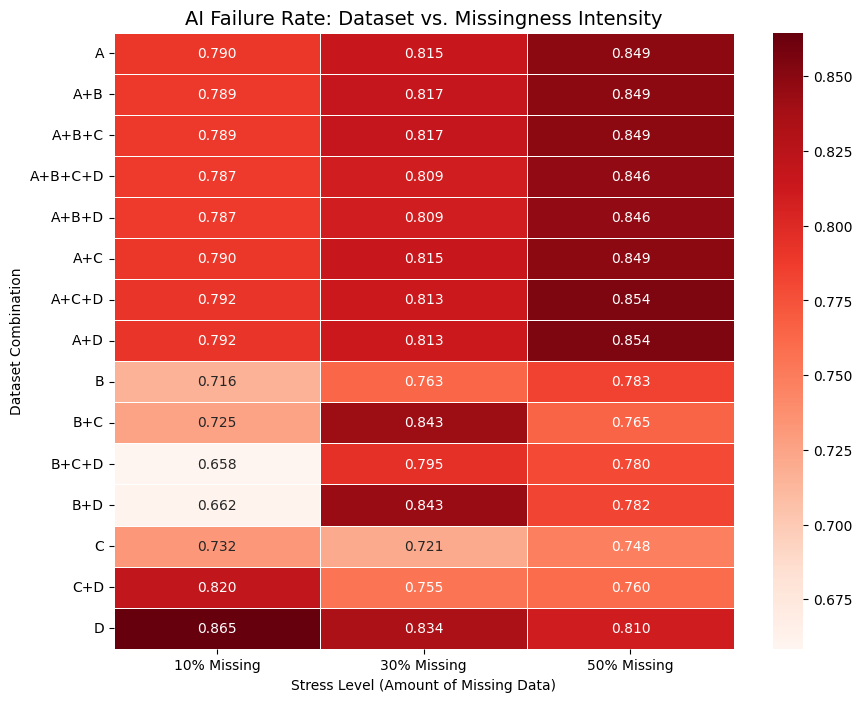

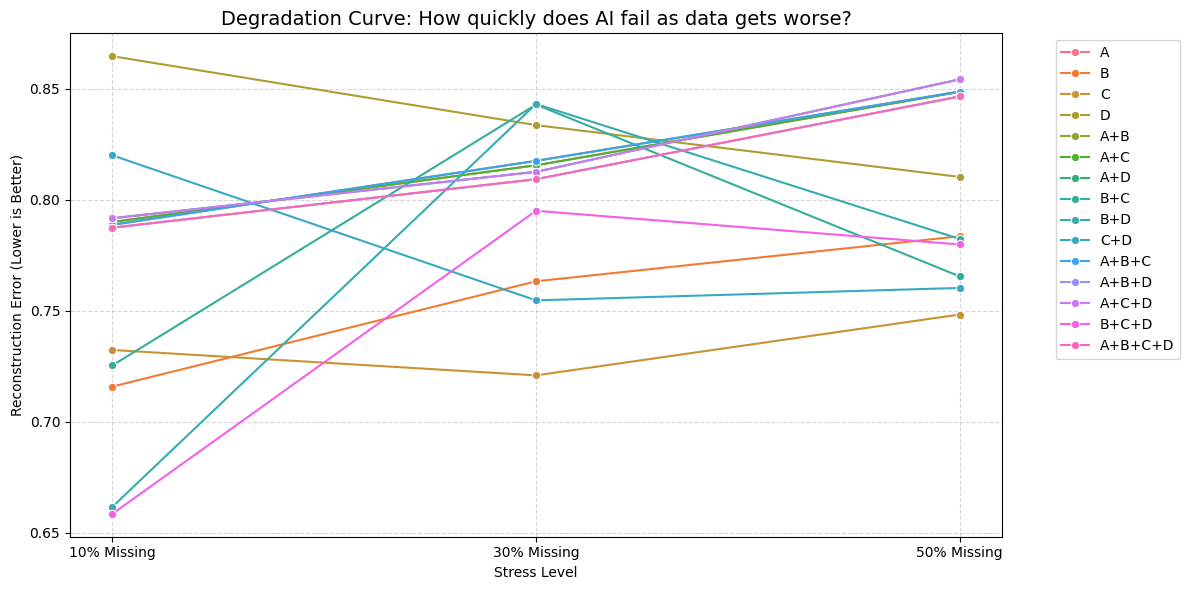


 STRESS TEST CHAMPION:
Even when **50% of the data was missing**, dataset **C**
maintained the lowest error rate of **0.7482**.


In [9]:
# ==========================================================
# 4. COMPREHENSIVE STRESS TEST: ALL COMBOS x 3 DAMAGE LEVELS
# ==========================================================
print("\n" + "="*60)
print(" RUNNING MULTI-LEVEL STRESS TEST")
print("   (Ensuring result for EVERY dataset combination)")
print("="*60)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

def run_adaptive_stress_test(name, df_raw, damage_ratio):

    # --- A. ADAPTIVE CLEANING
    df_clean = df_raw.dropna()

    # If dropping rows kills the dataset (e.g. Switzerland), drop bad columns instead
    if len(df_clean) < 20:
        # Calculate missingness per column
        miss_counts = df_raw.isnull().sum().sort_values(ascending=False)
        # Iteratively drop the worst column until we have at least 20 rows
        temp_df = df_raw.copy()
        for col in miss_counts.index:
            temp_df = temp_df.drop(col, axis=1)
            if len(temp_df.dropna()) >= 20:
                df_clean = temp_df.dropna()
                break

    # If STILL fail (extremely rare), return None
    if len(df_clean) < 10 or df_clean.shape[1] < 2:
        return None

    # --- B. PREPARE GROUND TRUTH ---
    scaler = StandardScaler()
    try:
        data_truth = scaler.fit_transform(df_clean)
    except:
        return None

    # --- C. INFLICT DAMAGE (The Stress Test) ---
    np.random.seed(42) # Fixed seed for fairness across datasets
    mask = np.random.rand(*data_truth.shape) < damage_ratio

    data_broken = data_truth.copy()
    data_broken[mask] = np.nan # Poke holes

    # --- D. AI RECOVERY ---
    imputer = KNNImputer(n_neighbors=5)
    data_healed = imputer.fit_transform(data_broken)

    # --- E. SCORE ---
    # Only score the specific values we broke
    error = mean_absolute_error(data_truth[mask], data_healed[mask])

    return {
        "Dataset": name,
        "Stress Level": f"{int(damage_ratio*100)}% Missing",
        "Error (MAE)": error,
        "Sample Size Used": len(df_clean),
        "Features Used": df_clean.shape[1]
    }

# --- EXECUTE LOOP ---
stress_results = []
damage_levels = [0.10, 0.30, 0.50] # 10%, 30%, 50% Missing

# Generate Combos
combos = []
for r in range(1, 5):
    combos.extend(itertools.combinations(datasets.keys(), r))

print(f"Testing {len(combos)} Datasets across {len(damage_levels)} Stress Levels...")

for combo in combos:
    combo_name = "+".join(combo)

    # Merge
    dfs_list = [datasets[k] for k in combo]
    df_combined = pd.concat(dfs_list, axis=0, ignore_index=True)

    # Run for each stress level
    for level in damage_levels:
        res = run_adaptive_stress_test(combo_name, df_combined, level)
        if res:
            stress_results.append(res)

print(" Stress Test Complete.")

# --- VISUALIZATION ---
df_stress = pd.DataFrame(stress_results)

# 1. HEATMAP: The best way to show 3 dimensions (Dataset x Stress x Error)
print("\n AI STABILITY HEATMAP (Darker = Higher Error/Worse)")
pivot_stress = df_stress.pivot(index="Dataset", columns="Stress Level", values="Error (MAE)")

# Reorder columns logically
pivot_stress = pivot_stress[['10% Missing', '30% Missing', '50% Missing']]

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_stress, annot=True, fmt=".3f", cmap="Reds", linewidths=0.5)
plt.title("AI Failure Rate: Dataset vs. Missingness Intensity", fontsize=14)
plt.ylabel("Dataset Combination")
plt.xlabel("Stress Level (Amount of Missing Data)")
plt.show()

# 2. LINE PLOT: Trend Analysis
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_stress, x="Stress Level", y="Error (MAE)", hue="Dataset", marker="o")
plt.title("Degradation Curve: How quickly does AI fail as data gets worse?", fontsize=14)
plt.ylabel("Reconstruction Error (Lower is Better)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 3. TOP PERFORMER
best_run = df_stress.loc[df_stress['Stress Level'] == '50% Missing'].sort_values('Error (MAE)').iloc[0]
print("\n STRESS TEST CHAMPION:")
print(f"Even when **50% of the data was missing**, dataset **{best_run['Dataset']}**")
print(f"maintained the lowest error rate of **{best_run['Error (MAE)']:.4f}**.")

SIMULATION COMPLETE.

 CHAMPION DATASETS FOR SINGLE MISSING VALUES


,Dataset,Error (MAE)
Missing Features,,
fbs,A+B+C+D,0.425057
ca,A+B+D,0.561428
thalach,A,0.591591
oldpeak,A+B+C+D,0.597764
thal,A+C,0.600772
cp,A+B+D,0.630450
exang,A+C,0.636087
age,A+B+D,0.636969
slope,A+B+D,0.654928



 PERFORMANCE MATRIX: PAIRWISE MISSING VALUES


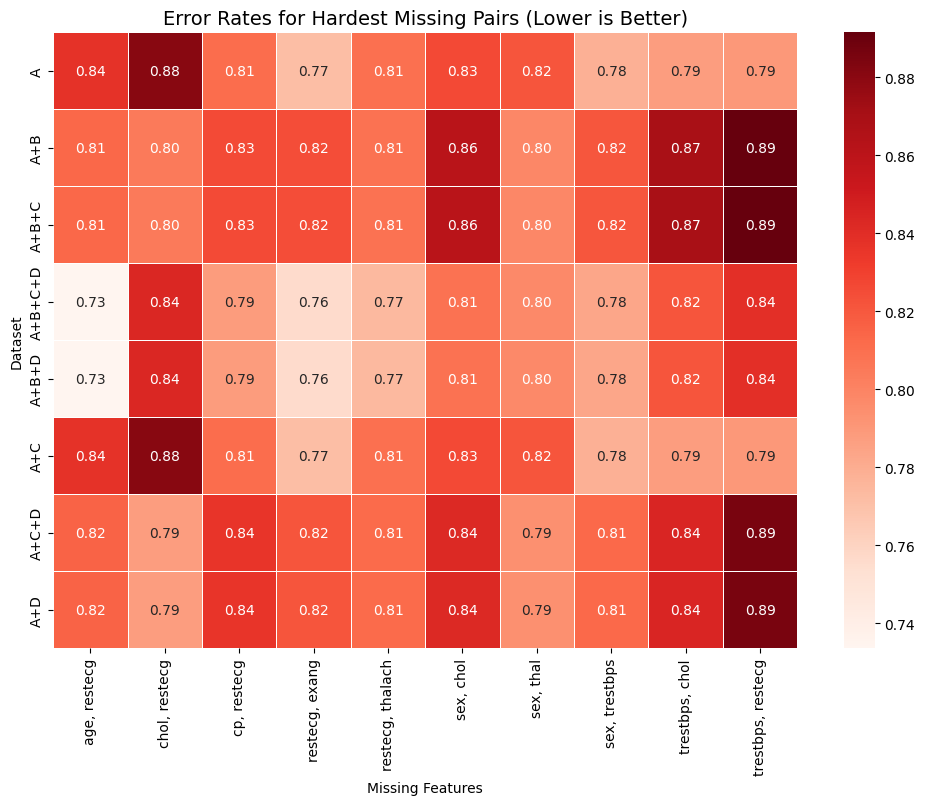

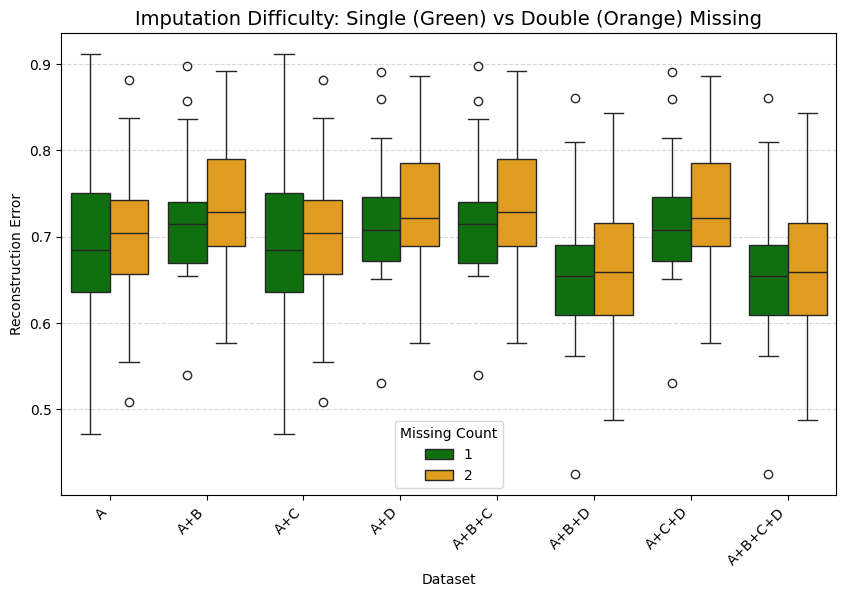

In [10]:
# ==========================================================
# 5. UNIVERSAL MISSING VALUE MATRIX (FIXED)
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from IPython.display import clear_output

print(" STARTING UNIVERSAL STRESS TEST (1,365 Simulations)...")

# 1. Define Features to Test
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
            'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

# 2. Generate Scenarios (1 missing & 2 missing)
scenarios = []
for f in features:
    scenarios.append([f])
for combo in itertools.combinations(features, 2):
    scenarios.append(list(combo))

print(f"Total Missing Patterns to Test: {len(scenarios)}")

# --- THE ENGINE ---
def run_fast_imputation_test(df_clean, missing_cols):
    """Runs imputation test on specific columns only"""
    # Check if columns exist in this specific dataset
    for col in missing_cols:
        if col not in df_clean.columns: return None

    scaler = StandardScaler()
    try:
        data_truth = scaler.fit_transform(df_clean)
        df_scaled = pd.DataFrame(data_truth, columns=df_clean.columns)
    except:
        return None

    data_broken = df_scaled.copy()
    np.random.seed(42)
    n_rows = len(df_scaled)

    # Hide data in 20% of rows
    mask_rows = np.random.choice(n_rows, size=int(n_rows*0.2), replace=False)

    for col in missing_cols:
        data_broken.loc[mask_rows, col] = np.nan

    # Heal
    imputer = KNNImputer(n_neighbors=5)
    data_healed = imputer.fit_transform(data_broken)
    df_healed = pd.DataFrame(data_healed, columns=df_clean.columns)

    # Score
    total_error = 0
    for col in missing_cols:
        truth = df_scaled.loc[mask_rows, col]
        guess = df_healed.loc[mask_rows, col]
        total_error += mean_absolute_error(truth, guess)

    return total_error / len(missing_cols)

# --- EXECUTE LOOP ---
full_results = []
dataset_combos = []
for r in range(1, 5):
    dataset_combos.extend(itertools.combinations(datasets.keys(), r))

total_steps = len(dataset_combos)
current_step = 0

for d_combo in dataset_combos:
    d_name = "+".join(d_combo)
    current_step += 1
    print(f"Processing Dataset {current_step}/{total_steps}: [{d_name}]...")

    # Prepare Dataset
    dfs_list = [datasets[k] for k in d_combo]
    df_merged = pd.concat(dfs_list, axis=0, ignore_index=True)

    # FIX: Added errors='ignore' to prevent crashing if target is already gone
    df_clean = df_merged.drop('target', axis=1, errors='ignore').dropna(axis=1, how='all').dropna()

    if len(df_clean) < 20:
        continue

    # Run Scenarios
    for scen in scenarios:
        scen_name = ", ".join(scen)
        error = run_fast_imputation_test(df_clean, scen)

        if error is not None:
            full_results.append({
                "Dataset": d_name,
                "Missing Features": scen_name,
                "Count": len(scen),
                "Error (MAE)": error
            })

clear_output()
print("SIMULATION COMPLETE.")

# --- VISUALIZATION ---
if not full_results:
    print(" No results generated. Check data loading.")
else:
    df_res = pd.DataFrame(full_results)

    # 1. BEST DATASET FOR TOP MISSING FEATURES
    print("\n CHAMPION DATASETS FOR SINGLE MISSING VALUES")
    single_missing = df_res[df_res['Count'] == 1].sort_values('Error (MAE)')
    best_singles = single_missing.groupby('Missing Features').first().sort_values('Error (MAE)')
    display(best_singles[['Dataset', 'Error (MAE)']])

    # 2. HEATMAP FOR PAIRS
    print("\n PERFORMANCE MATRIX: PAIRWISE MISSING VALUES")
    pairs = df_res[df_res['Count'] == 2]
    if not pairs.empty:
        hardest_pairs = pairs.groupby('Missing Features')['Error (MAE)'].mean().nlargest(10).index
        subset = pairs[pairs['Missing Features'].isin(hardest_pairs)]

        pivot_pairs = subset.pivot(index="Dataset", columns="Missing Features", values="Error (MAE)")

        plt.figure(figsize=(12, 8))
        sns.heatmap(pivot_pairs, annot=True, fmt=".2f", cmap="Reds", linewidths=0.5)
        plt.title("Error Rates for Hardest Missing Pairs (Lower is Better)", fontsize=14)
        plt.show()

    # 3. SCATTER PLOT
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="Dataset", y="Error (MAE)", hue="Count", data=df_res, palette={1:"green", 2:"orange"})
    plt.title("Imputation Difficulty: Single (Green) vs Double (Orange) Missing", fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Reconstruction Error")
    plt.legend(title="Missing Count")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

 OPTIMIZATION COMPLETE.

 MASTER LOOKUP TABLE: BEST DATASET FOR EVERY PAIR


,Missing Pair,Best Dataset,Lowest Error (MAE)
53,fbs & oldpeak,A+B+D,0.487173
51,fbs & thalach,A,0.508652
54,fbs & slope,A+B+D,0.521404
4,age & fbs,A+B+D,0.523623
56,fbs & thal,A+B+D,0.541490
55,fbs & ca,A+B+D,0.557239
52,fbs & exang,A+B+D,0.559504
77,ca & thal,A+B+D,0.560997
25,cp & fbs,A+B+D,0.565993
15,sex & fbs,A+B+D,0.574323



 DATASET DOMINANCE: Which combo wins the most pairs?


/tmp/ipykernel_10327/1276122342.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=win_counts.values, y=win_counts.index, palette='viridis')


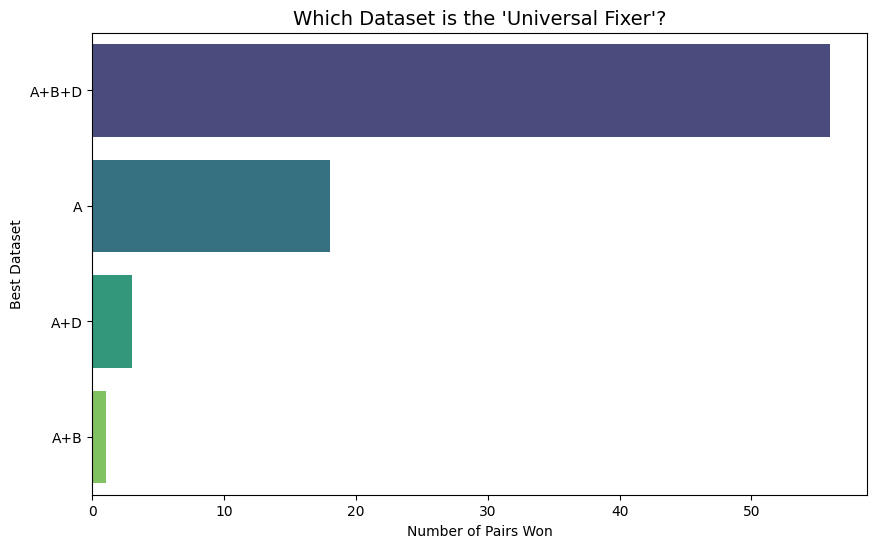

In [11]:
# ==========================================================
# 5. MASTER LOOKUP TABLE: BEST DATASET FOR EVERY MISSING PAIR
# ==========================================================
import pandas as pd
import numpy as np
import itertools
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from IPython.display import clear_output

print(" STARTING EXHAUSTIVE PAIRWISE OPTIMIZATION...")

# 1. Define Features
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
            'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

# 2. Generate All 78 Pairs
pairs = list(itertools.combinations(features, 2))
print(f"Evaluating {len(pairs)} missing feature pairs across 15 datasets...")

# 3. Define the Tester Function
def test_pair_accuracy(df_clean, pair):
    """Returns the imputation error for a specific pair of missing columns"""
    # Check if columns exist
    if pair[0] not in df_clean.columns or pair[1] not in df_clean.columns:
        return 9999.0 # High penalty for missing columns

    scaler = StandardScaler()
    try:
        data_truth = scaler.fit_transform(df_clean)
        df_scaled = pd.DataFrame(data_truth, columns=df_clean.columns)
    except:
        return 9999.0

    # Hide Data
    data_broken = df_scaled.copy()
    np.random.seed(42)
    mask_rows = np.random.choice(len(df_scaled), size=int(len(df_scaled)*0.2), replace=False)

    for col in pair:
        data_broken.loc[mask_rows, col] = np.nan

    # Heal
    imputer = KNNImputer(n_neighbors=5)
    data_healed = imputer.fit_transform(data_broken)

    # Calculate Average Error across the pair
    df_healed = pd.DataFrame(data_healed, columns=df_clean.columns)

    total_error = 0
    for col in pair:
        truth = df_scaled.loc[mask_rows, col]
        guess = df_healed.loc[mask_rows, col]
        total_error += mean_absolute_error(truth, guess)

    return total_error / 2

# 4. EXECUTE LOOP
best_datasets_for_pair = []

# Pre-load datasets to save time
loaded_combos = {}
dataset_combos = []
for r in range(1, 5):
    dataset_combos.extend(itertools.combinations(datasets.keys(), r))

for combo in dataset_combos:
    name = "+".join(combo)
    dfs = [datasets[k] for k in combo]
    df_merged = pd.concat(dfs, axis=0, ignore_index=True)
    # Clean it once
    df_clean = df_merged.drop('target', axis=1, errors='ignore').dropna(axis=1, how='all').dropna()
    if len(df_clean) > 20:
        loaded_combos[name] = df_clean

# Loop through every pair
for i, pair in enumerate(pairs):
    pair_name = f"{pair[0]} & {pair[1]}"
    if i % 10 == 0: print(f"Processing Pair {i}/{len(pairs)}: {pair_name}...")

    best_score = 9999.0
    best_ds = "None"

    # Check this pair against ALL valid datasets
    for ds_name, df_data in loaded_combos.items():
        score = test_pair_accuracy(df_data, pair)
        if score < best_score:
            best_score = score
            best_ds = ds_name

    best_datasets_for_pair.append({
        "Missing Pair": pair_name,
        "Best Dataset": best_ds,
        "Lowest Error (MAE)": best_score
    })

clear_output()
print(" OPTIMIZATION COMPLETE.")

# --- 5. VISUALIZATION ---
df_results = pd.DataFrame(best_datasets_for_pair).sort_values(by="Lowest Error (MAE)")

# A. THE MASTER LOOKUP TABLE
print("\n MASTER LOOKUP TABLE: BEST DATASET FOR EVERY PAIR")
print("="*60)
pd.set_option('display.max_rows', None)
display(df_results)
pd.reset_option('display.max_rows')

# B. WHICH DATASET WINS THE MOST?
print("\n DATASET DOMINANCE: Which combo wins the most pairs?")
win_counts = df_results['Best Dataset'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=win_counts.values, y=win_counts.index, palette='viridis')
plt.title("Which Dataset is the 'Universal Fixer'?", fontsize=14)
plt.xlabel("Number of Pairs Won")
plt.show()